<a href="https://colab.research.google.com/github/SpiderFang/MolecularDescriptors-rdkit/blob/main/molecular_descritors_rdkit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generating Molecular Descriptors Using RDKit


In [12]:
# Install RDKit
!pip install rdkit

In [13]:
# Importing Libraries
import pandas as pd
import warnings

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem, PandasTools
from rdkit.ML.Descriptors import MoleculeDescriptors

warnings.filterwarnings("ignore")

In [14]:
import os
import pandas as pd # Ensure pandas is imported here if not globally

# Install openpyxl if not already installed
# openpyxl is needed to read .xlsx files
!pip install openpyxl

# Check if the file exists before attempting to read it.
# If you haven't uploaded 'Heteroaromatics.xlsx' yet, please do so.
# You can upload it by clicking the folder icon on the left sidebar,
# then selecting the 'Upload' icon and choosing your file.

file_path = '/content/Heteroaromatics.xlsx'

if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found. Please upload it to Colab.")
    # If you uploaded the file to a different path, update 'file_path' accordingly.
    raise FileNotFoundError(f"File not found: {file_path}. Please upload the file 'Heteroaromatics.xlsx'.")
else:
    # Specify the engine as 'openpyxl' for .xlsx files
    df = pd.read_excel(file_path, engine='openpyxl')
    print(f"Successfully loaded '{file_path}'.")

Successfully loaded '/content/Heteroaromatics.xlsx'.


In [15]:
df.head()

,Smiles
0,CN1C=CC=C1
1,C1=CC=CN1
2,C1=CN=CC=C1
3,CC1=NC=CC=C1
4,CC1=CC=NC=C1


In [16]:
# Creating molecular object from Smiles

# PandasTools.AddMoleculeColumnToFrame(df,'Smiles','mol')

In [17]:
df

,Smiles
0,CN1C=CC=C1
1,C1=CC=CN1
2,C1=CN=CC=C1
3,CC1=NC=CC=C1
4,CC1=CC=NC=C1
5,CC1=C(C)C=NC=C1
6,CC1=NC(C)=CC=C1
7,CC(C)(C)C1=NC(C(C)(C)C)=CC=C1
8,CC1=NC(C)=CC(C)=C1
9,FC1=NC=CC=C1


Create an object of the molecule descriptor class

In [18]:
mol_list = []

for smile in df['Smiles']:
  mol = Chem.MolFromSmiles(smile)
  mol = Chem.AddHs(mol)
  mol_list.append(mol)

df = pd.concat([df, pd.DataFrame(mol_list, columns = (['mol']))], axis=1)

In [19]:
df.head()

,Smiles,mol
0,CN1C=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5ac70>
1,C1=CC=CN1,<rdkit.Chem.rdchem.Mol object at 0x789e47e59a80>
2,C1=CN=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5aab0>
3,CC1=NC=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5b300>
4,CC1=CC=NC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5a810>


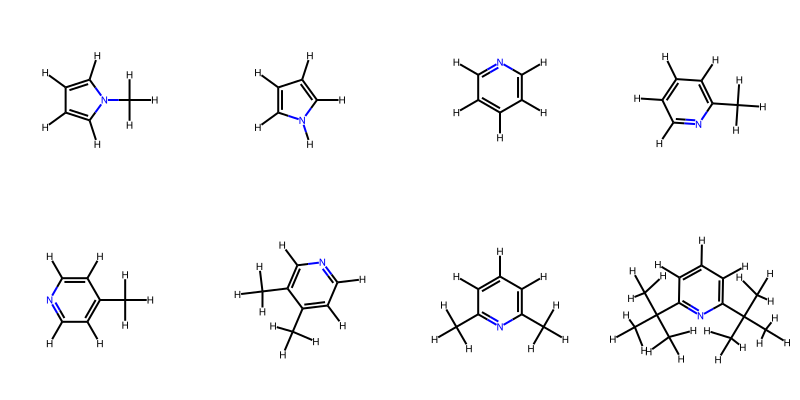

In [20]:
Draw.MolsToGridImage(df['mol'][:8],molsPerRow=4,subImgSize=(200,200))

Create an instance of the class to print names and number of descriptors

In [21]:
Desc_list_func = MoleculeDescriptors.MolecularDescriptorCalculator(x[0] for x in Descriptors._descList)

In [22]:
Desc_list_func

Call the instance to get names

In [23]:
names = Desc_list_func.GetDescriptorNames()

Print the names of descriptors

In [24]:
names

('MaxAbsEStateIndex',
 'MaxEStateIndex',
 'MinAbsEStateIndex',
 'MinEStateIndex',
 'qed',
 'SPS',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'NumValenceElectrons',
 'NumRadicalElectrons',
 'MaxPartialCharge',
 'MinPartialCharge',
 'MaxAbsPartialCharge',
 'MinAbsPartialCharge',
 'FpDensityMorgan1',
 'FpDensityMorgan2',
 'FpDensityMorgan3',
 'BCUT2D_MWHI',
 'BCUT2D_MWLOW',
 'BCUT2D_CHGHI',
 'BCUT2D_CHGLO',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'BCUT2D_MRHI',
 'BCUT2D_MRLOW',
 'AvgIpc',
 'BalabanJ',
 'BertzCT',
 'Chi0',
 'Chi0n',
 'Chi0v',
 'Chi1',
 'Chi1n',
 'Chi1v',
 'Chi2n',
 'Chi2v',
 'Chi3n',
 'Chi3v',
 'Chi4n',
 'Chi4v',
 'HallKierAlpha',
 'Ipc',
 'Kappa1',
 'Kappa2',
 'Kappa3',
 'LabuteASA',
 'PEOE_VSA1',
 'PEOE_VSA10',
 'PEOE_VSA11',
 'PEOE_VSA12',
 'PEOE_VSA13',
 'PEOE_VSA14',
 'PEOE_VSA2',
 'PEOE_VSA3',
 'PEOE_VSA4',
 'PEOE_VSA5',
 'PEOE_VSA6',
 'PEOE_VSA7',
 'PEOE_VSA8',
 'PEOE_VSA9',
 'SMR_VSA1',
 'SMR_VSA10',
 'SMR_VSA2',
 'SMR_VSA3',
 'SMR_VSA4',
 'SMR_VSA5',
 'SMR_VSA6',


In [25]:
len(names)

217

Again create an object of the molecule descriptor class

1. Get Summary of the descriptors
2. Generate molecular descriptors

In [26]:
MoleculeDescriptors.MolecularDescriptorCalculator(['MolLogP']).GetDescriptorSummaries()

['Wildman-Crippen LogP value']

In [27]:
# create another instance for calculating molecular descriptors

Des_func = MoleculeDescriptors.MolecularDescriptorCalculator(['NumHeteroatoms', 'NumHDonors'])

In [28]:
Des_func

Calculate one descriptor for a sinlge molecule

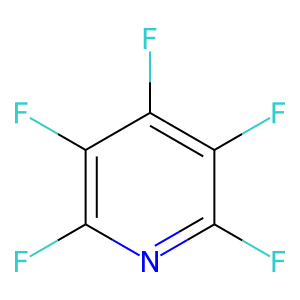

(6, 0)

In [29]:
display(Draw.MolToImage(df['mol'][12]))
Des_func.CalcDescriptors(df['mol'][12])

Calculate one or more descriptor for the whole dataset

In [30]:
des = []

for mol in df['mol']:
  des.append(Des_func.CalcDescriptors(mol))

In [31]:
Final_df = pd.concat([df, pd.DataFrame(des, columns=(['NumHeteroatoms', 'NumHDonors']))], axis=1)

In [32]:
Final_df.head()

,Smiles,mol,NumHeteroatoms,NumHDonors
0,CN1C=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5ac70>,1,0
1,C1=CC=CN1,<rdkit.Chem.rdchem.Mol object at 0x789e47e59a80>,1,1
2,C1=CN=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5aab0>,1,0
3,CC1=NC=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5b300>,1,0
4,CC1=CC=NC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5a810>,1,0


Calculate all the descriptor for the whole dataset

In [33]:
# create another instance for calculating molecular descriptors

Des_func = MoleculeDescriptors.MolecularDescriptorCalculator(x[0] for x in Descriptors._descList)

In [34]:
des = []

for mol in df['mol']:
  des.append(Des_func.CalcDescriptors(mol))

In [35]:
Final_df = pd.concat([df, pd.DataFrame(des, columns=(x[0] for x in Descriptors._descList))], axis=1)

In [36]:
Final_df.head()

,Smiles,mol,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,CN1C=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5ac70>,7.188079,7.188079,0.386574,-2.663426,0.439206,27.666667,81.118,74.062,...,0,0,0,0,0,0,0,0,0,0
1,C1=CC=CN1,<rdkit.Chem.rdchem.Mol object at 0x789e47e59a80>,6.969907,6.969907,0.361111,-0.407407,0.465869,22.000000,67.091,62.051,...,0,0,0,0,0,0,0,0,0,0
2,C1=CN=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5aab0>,7.070741,7.070741,0.397222,-0.420370,0.453148,19.666667,79.102,74.062,...,0,0,0,0,0,0,0,0,0,0
3,CC1=NC=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5b300>,7.275116,7.275116,0.525000,-2.614699,0.471998,24.857143,93.129,86.073,...,0,0,0,0,0,0,0,0,0,0
4,CC1=CC=NC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5a810>,7.275116,7.275116,0.581019,-2.650093,0.471998,24.857143,93.129,86.073,...,0,0,0,0,0,0,0,0,0,0


In [37]:
Final_df.drop('mol', axis=1).to_excel('final.xlsx', index=None)